In [119]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
def I_func(t, eps, I_bar):
    return I_bar + eps*np.sin(2*np.pi*t)

In [66]:
def ode_solver(t_end, t_step, v_0, eps, I_bar):
    len_t = int(t_end/t_step)
    t_vals = np.linspace(0,t_end, len_t+1)
    v_vals = np.zeros(len_t+1)
    v_vals[0] = v_0
    
    for s in range(1,len(t_vals)):
        if v_vals[s-1] > 1:
            v_vals[s] = 0
        else:
            dv_dt = -1*v_vals[s-1] + I_func(t_vals[s-1], eps, I_bar)
            v_vals[s] = v_vals[s-1] + t_step*dv_dt

    # now we have to find the spikes per forcing period after a transient period
    # discard the first 10 ms
    discard_idx = int(10 / t_step)
    t_vals2 = t_vals[discard_idx:]
    v_vals2 = v_vals[discard_idx:]

    total_sec     = t_end - 10
    total_spikes  = sum(v_vals2 > 1)
    firing_number = total_spikes / total_sec
    return t_vals,v_vals, firing_number

In [56]:
t_test, v_test, firing_number = ode_solver(100, .01, 0, .5, 2)

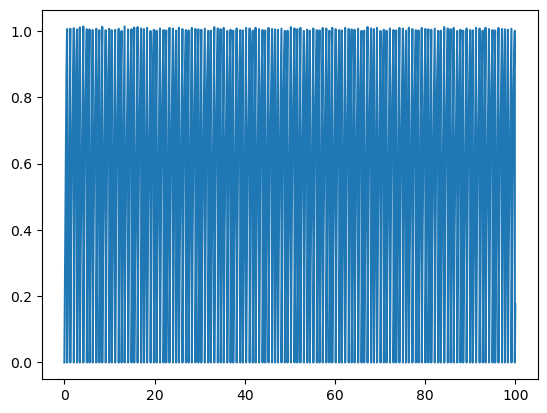

In [58]:
plt.plot(t_test, v_test)

In [128]:
# now we are going to loop this with different values of I_bar
eps = .5
I_bar_vec = np.linspace(.9,3, 300)
f_vec = np.zeros(len(I_bar_vec))
for q in range(len(I_bar_vec)):
    _, _, f = ode_solver(100, .01, 0, .5, I_bar_vec[q])
    f_vec[q] = f

In [132]:
# lets also find the unforced firing number(ufn)

ufn = [1/(np.log(I/(I - 1))) if I > 1 else 0 for I in I_bar_vec]
i_star = np.e/(np.e - 1)
upper, lower = i_star + eps / np.sqrt(4*np.pi**2 + 1), i_star - eps / np.sqrt(4*np.pi**2 + 1) 

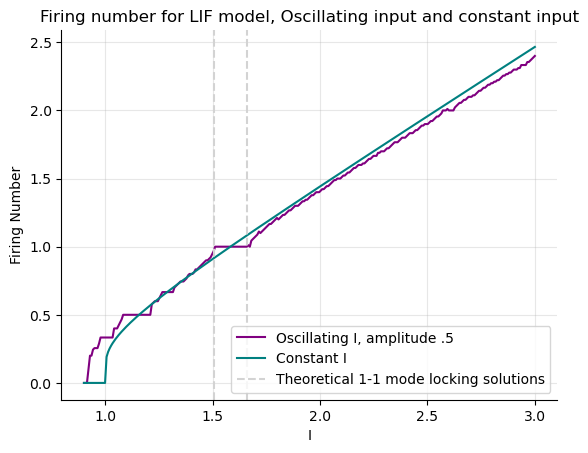

In [158]:
plt.plot(I_bar_vec, f_vec, color = "purple", label = "Oscillating I, amplitude .5")
plt.plot(I_bar_vec, ufn, color = "teal", label = "Constant I")
plt.axvline(x = upper, linestyle = "--", color = "lightgrey", label = "Theoretical 1-1 mode locking solutions")
plt.axvline(x = lower, linestyle = "--", color = "lightgrey")

plt.legend()
plt.xlabel("I")
plt.ylabel("Firing Number")
plt.title("Firing number for LIF model, Oscillating input and constant input")

sns.despine()
plt.grid(alpha = .3)
plt.savefig("mode_locking", dpi=300, bbox_inches="tight")
plt.show()

In [143]:
# now we have to find the phase when I = 1.6, which requires us to keep track of something slightly different in the function
def ode_solver2(t_end, t_step, v_0, eps, I_bar):
    len_t = int(t_end/t_step)
    t_vals = np.linspace(0,t_end, len_t+1)
    v_vals = np.zeros(len_t+1)
    v_vals[0] = v_0
    
    for s in range(1,len(t_vals)):
        if v_vals[s-1] > 1:
            v_vals[s] = 0
        else:
            dv_dt = -1*v_vals[s-1] + I_func(t_vals[s-1], eps, I_bar)
            v_vals[s] = v_vals[s-1] + t_step*dv_dt

    # now we have to find the spikes per forcing period after a transient period
    # discard the first 10 ms
    discard_idx = int(10 / t_step)
    t_vals2 = t_vals[discard_idx:]
    v_vals2 = v_vals[discard_idx:]

    total_sec     = t_end - 10
    total_spikes  = sum(v_vals2 > 1)
    spike_indices = [index for index, value in enumerate(v_vals2) if value > 1]
    spike_times = t_vals2[spike_indices]
    firing_number = total_spikes / total_sec
    return t_vals,v_vals, firing_number, spike_times

In [153]:
_, _, f, s_times = ode_solver2(100, .01, 0, .5, 1.6)

In [155]:
s_times

array([10.21, 11.21, 12.21, 13.21, 14.21, 15.21, 16.21, 17.21, 18.21,
       19.21, 20.21, 21.21, 22.21, 23.21, 24.21, 25.21, 26.21, 27.21,
       28.21, 29.21, 30.21, 31.21, 32.21, 33.21, 34.21, 35.21, 36.21,
       37.21, 38.21, 39.21, 40.21, 41.21, 42.21, 43.21, 44.21, 45.21,
       46.21, 47.21, 48.21, 49.21, 50.21, 51.21, 52.21, 53.21, 54.21,
       55.21, 56.21, 57.21, 58.21, 59.21, 60.21, 61.21, 62.21, 63.21,
       64.21, 65.21, 66.21, 67.21, 68.21, 69.21, 70.21, 71.21, 72.21,
       73.21, 74.21, 75.21, 76.21, 77.21, 78.21, 79.21, 80.21, 81.21,
       82.21, 83.21, 84.21, 85.21, 86.21, 87.21, 88.21, 89.21, 90.21,
       91.21, 92.21, 93.21, 94.21, 95.21, 96.21, 97.21, 98.21, 99.21])